# Pré-processamento
## Parte 1: Configurações, Constantes, Funções Utilitárias e validação estrutural do RAW

### O que esta parte faz?
Iremos:
- Importar as bibliotecas necessárias
- Definir todos os caminhos de arquivo em um só lugar
- Declarar constantes (frequências, nomes de colunas, mapeamentos)
- Criar funções utilitárias que as outras partes reusam
- Faz a **validação estrutural do RAW** — checa se o dado bruto é utilizável antes de tentar processar qualquer coisa

### Ponto de partida obrigatório
Todo o pipeline começa em **`data/bronze/full_table.parquet`**.
Esse arquivo foi gerado pelo notebook `build_bronze_raw` e contém:
- Sinais EEG (1000 Hz), IMU (100 Hz), BIO — todos concatenados numa tabela única
- Colunas: `timestamp`, `patient_id`, `task_id`, `session` + canais de sinal
- **`label` completamente vazio (NaN)** — os labels reais estão nos `task_*.parquet`
  mas esses arquivos NÃO entram como input do pipeline. Servem apenas para
  comparação na Parte 4, depois que o nosso processamento estiver pronto.

---
### Entrada - Parte 1
- `data/bronze/full_table.parquet`

### Saída desta parte
- Nenhum arquivo gerado — apenas variáveis e funções em memória
- Um relatório impresso de validação do RAW
---

## 1. Importações

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import signal as sg      # filtros digitais (usado nas partes 2 e 3)
import scipy.interpolate as spi     # interpolação spline para o resample do IMU

print("Bibliotecas carregadas com sucesso.")

Bibliotecas carregadas com sucesso.


## 2. Caminhos de Arquivo

In [5]:
# Raiz do projeto (assumindo que o notebook está em /notebooks)
ROOT = Path("..")  

# Entrada: tabela bruta gerada pelo build_bronze_raw
# Contém: EEG (1000Hz) + IMU (100Hz) + metadados, timestamp relativo, sem label
RAW_PATH = ROOT / "data" / "bronze" / "full_table.parquet"

# Entrada: tabela filtrada com labels e task_id já preenchidos
# Contém: dado já organizado por tarefa e com coluna label (0=normal, 1=FOG)
FILTERED_REF_PATH = ROOT / "data" / "bronze" / "filtered_parquet"

# ── Saídas intermediárias (geradas pelas partes 2, 3 e 4) ────────────────────
SILVER_PATH      = ROOT / "data" / "silver"
RESAMPLED_PATH   = SILVER_PATH / "resampled.parquet"    # saída da Parte 2
FILTERED_PATH    = SILVER_PATH / "filtered.parquet"     # saída da Parte 3
NORMALIZED_PATH  = SILVER_PATH / "normalized.parquet"   # saída da Parte 4

SILVER_PATH.mkdir(parents=True, exist_ok=True)

print(f"RAW (entrada):       {RAW_PATH}")
print(f"Referência (Parte4): {FILTERED_REF_PATH}")
print(f"Silver (saídas):     {SILVER_PATH}")

RAW (entrada):       ../data/bronze/full_table.parquet
Referência (Parte4): ../data/bronze/filtered_parquet
Silver (saídas):     ../data/silver


## 3. Constantes do Pipeline

In [6]:
# ── Frequências de amostragem ─────────────────────────────────────────────────
# O EEG foi gravado a 1000 pontos por segundo (1 ponto a cada 1ms)
EEG_FREQ_HZ = 1000

# Os sensores IMU (acelerômetro + giroscópio) foram gravados a 100 pontos/segundo
# (1 ponto a cada 10ms — 10x mais lento que o EEG)
IMU_FREQ_HZ = 100

# Frequência alvo após resample na Parte 2
# 500Hz é o meio-termo: boa resolução para EEG de FOG, arquivo manejável
TARGET_FREQ_HZ = 500

# Intervalo entre amostras no dado final (em segundos)
TARGET_DT = 1.0 / TARGET_FREQ_HZ   # = 0.002s = 2ms

# Fatores de conversão de frequência
# EEG: pegar 1 de cada 2 amostras (1000 → 500Hz)
EEG_DOWN_FACTOR = EEG_FREQ_HZ // TARGET_FREQ_HZ   # = 2

# IMU: inserir 4 amostras interpoladas entre cada par de amostras reais (100 → 500Hz)
IMU_UP_FACTOR = TARGET_FREQ_HZ // IMU_FREQ_HZ     # = 5

print(f"EEG:  {EEG_FREQ_HZ}Hz → downsample ÷{EEG_DOWN_FACTOR} → {TARGET_FREQ_HZ}Hz")
print(f"IMU:  {IMU_FREQ_HZ}Hz  → upsample  ×{IMU_UP_FACTOR}  → {TARGET_FREQ_HZ}Hz")
print(f"Intervalo entre amostras no output: {TARGET_DT*1000:.1f}ms")

# ── Limiar de sensor morto ────────────────────────────────────────────────────
# Um sensor 'morto' registrou cabo solto ou eletrodo sem contato:
# quase todos os valores são zero ou ruído de fundo insignificante.
# Exemplo: LShank-ACCX com 97% dos valores < 1e-8 → sensor morto
ZERO_EPS         = 1e-8   # amplitude mínima para considerar 'tem sinal'
MISSING_THRESH   = 0.95   # 95% dos valores abaixo de ZERO_EPS → morto

# ── Rede elétrica ─────────────────────────────────────────────────────────────
#  Brasil = 60Hz  |  Europa/China = 50Hz
# O ruído da tomada contamina o EEG nessa frequência específica
FREQ_REDE_HZ = 50.0

print(f"\nFrequência da rede elétrica: {FREQ_REDE_HZ}Hz")
print(f"Sensor morto se >{MISSING_THRESH*100:.0f}% dos valores < {ZERO_EPS}")

EEG:  1000Hz → downsample ÷2 → 500Hz
IMU:  100Hz  → upsample  ×5  → 500Hz
Intervalo entre amostras no output: 2.0ms

Frequência da rede elétrica: 50.0Hz
Sensor morto se >95% dos valores < 1e-08


## 4. Nomes de Colunas

In [7]:
# ── EEG: 25 canais do sistema 10-20 internacional ────────────────────────────
# Cada nome é uma posição no couro cabeludo:
# FP=frontal polar, F=frontal, C=central, P=parietal, O=occipital
# Z=linha média, números ímpares=esquerda, pares=direita
EEG_COLS = [
    'EEG-FP1', 'EEG-FP2',
    'EEG-F3',  'EEG-F4',
    'EEG-C3',  'EEG-C4',
    'EEG-P3',  'EEG-P4',
    'EEG-O1',  'EEG-O2',
    'EEG-F7',  'EEG-F8',
    'EEG-P7',  'EEG-P8',
    'EEG-FZ',  'EEG-CZ',  'EEG-PZ',
    'EEG-FC1', 'EEG-FC2',
    'EEG-CP1', 'EEG-CP2',
    'EEG-FC5', 'EEG-FC6',
    'EEG-CP5', 'EEG-CP6'
]

# 5 canais de biosinais (EMG = músculo, IO = eletrodo ocular, ECG = coração)
BIO_COLS = ['EMG-RTA', 'EMG-LTA', 'EMG-RGS', 'IO', 'ECG']
EMG_COLS = ['EMG-RTA', 'EMG-LTA', 'EMG-RGS']  # subset dos biosinais

# ── IMU: 4 sensores × 7 colunas cada ─────────────────────────────────────────
# ACC(X,Y,Z) = acelerômetro nos 3 eixos espaciais
# GYRO(X,Y,Z) = giroscópio nos 3 eixos (velocidade angular)
# NC/SC = canal auxiliar (Not Connected ou Skin Conductance no braço)
SENSOR_NAMES = ['LShank', 'RShank', 'Waist', 'Arm']
IMU_SUFFIXES_SINAL = ['ACCX', 'ACCY', 'ACCZ', 'GYRO-X', 'GYRO-Y', 'GYRO-Z']
IMU_SUFFIXES_ALL   = IMU_SUFFIXES_SINAL + ['NC/SC']
IMU_COLS_SINAL = [f"{s}-{ax}" for s in SENSOR_NAMES for ax in IMU_SUFFIXES_SINAL]
IMU_COLS_ALL   = [f"{s}-{ax}" for s in SENSOR_NAMES for ax in IMU_SUFFIXES_ALL]
# Resultado: ['LShank-ACCX', 'LShank-ACCY', ..., 'Arm-GYRO-Z', 'Arm-NC/SC']

# Colunas de metadados e controle
META_COLS = ['timestamp', 'patient_id', 'task_id', 'session']


# ── Schema completo na ordem do output final ──────────────────────────────────
ALL_SIGNAL_COLS = EEG_COLS + BIO_COLS + IMU_COLS_ALL
ALL_COLS        = META_COLS + ALL_SIGNAL_COLS + ['label']

print(f"EEG:   {len(EEG_COLS)} canais")
print(f"BIO:   {len(BIO_COLS)} canais")
print(f"IMU:   {len(IMU_COLS_ALL)} colunas  ({len(SENSOR_NAMES)} sensores × {len(IMU_SUFFIXES_ALL)})")
print(f"META:  {len(META_COLS)} colunas")
print(f"Total de colunas de sinal: {len(ALL_SIGNAL_COLS)}")
print(f"Total de colunas: {len(ALL_COLS)}")

EEG:   25 canais
BIO:   5 canais
IMU:   28 colunas  (4 sensores × 7)
META:  4 colunas
Total de colunas de sinal: 58
Total de colunas: 63


## 5. Funções Utilitárias

In [8]:
def sensor_morto(valores: np.ndarray) -> bool:
    """
    Retorna True se o canal estiver essencialmente zerado.
    Indica cabo solto, eletrodo sem contato ou sensor não conectado.

    Exemplo:
        sensor_morto([0.0, 0.0, 0.0, 0.0, 0.5])  → False  (só 80% zero)
        sensor_morto([0.0, 0.0, 0.0, 0.0, 0.0])  → True   (100% zero)
    """
    proporcao_zero = np.mean(np.abs(valores) < ZERO_EPS)
    return proporcao_zero > MISSING_THRESH


def listar_pacientes(df: pd.DataFrame) -> list:
    """
    Retorna lista ordenada de patient_id únicos no DataFrame.
    O pipeline itera sobre essa lista em cada etapa.
    """
    pacientes = sorted(df['patient_id'].unique().tolist())
    print(f"{len(pacientes)} pacientes: {pacientes}")
    return pacientes


def relatorio_nans(df: pd.DataFrame, titulo: str = "", so_sinais: bool = True) -> None:
    """
    Imprime um relatório de valores ausentes por coluna.
    so_sinais=True → mostra só colunas de sinal (ignora metadata)

    Exemplo de saída:
        LShank-ACCX:    100.0% NaN  ← sensor ausente
        EEG-FP1:          0.0% NaN  ← ok
    """
    if titulo:
        print(f"\n{'='*55}\n  NaNs — {titulo}\n{'='*55}")

    colunas = ALL_SIGNAL_COLS if so_sinais else df.columns.tolist()
    colunas = [c for c in colunas if c in df.columns]

    nan_pct = (df[colunas].isna().sum() / len(df) * 100).sort_values(ascending=False)
    cols_com_nan = nan_pct[nan_pct > 0]

    if cols_com_nan.empty:
        print("  Nenhum NaN encontrado.")
    else:
        for col, pct in cols_com_nan.items():
            barra = '█' * int(pct / 5)   # barra visual proporcional
            print(f"  {col:<28} {pct:6.1f}%  {barra}")


def listar_tasks_parquet(patient_id: str) -> list:
    """
    Lista os arquivos task_*.parquet disponíveis para um paciente
    na pasta de referência (filtered_parquet).
    Usado APENAS na Parte 4 para comparação — não é input do pipeline.

    Exemplo:
        listar_tasks_parquet('001')
        → ['task_1.parquet', 'task_2.parquet', 'task_3.parquet']
    """
    pasta = FILTERED_REF_PATH / patient_id
    if not pasta.exists():
        print(f"Pasta de referência não encontrada: {pasta}")
        return []
    tasks = sorted(pasta.glob("task_*.parquet"))
    return [t.name for t in tasks]


def carregar_task_referencia(patient_id: str, task_name: str) -> pd.DataFrame:
    """
    Carrega um task_*.parquet de referência para um paciente.
    Usado APENAS na Parte 4 para comparação.

    Exemplo:
        carregar_task_referencia('001', 'task_1.parquet')
    """
    caminho = FILTERED_REF_PATH / patient_id / task_name
    if not caminho.exists():
        print(f"Arquivo não encontrado: {caminho}")
        return pd.DataFrame()
    return pd.read_parquet(caminho)


def filtrar_paciente(df: pd.DataFrame, patient_id: str, session: str = None) -> pd.DataFrame:
    mask = df['patient_id'] == patient_id
    if session is not None:
        mask = mask & (df['session'] == session)
    resultado = df[mask].copy()
    print(f"  Paciente {patient_id} (sessão {session or 'todas'}): {len(resultado):,} amostras")
    return resultado

print("Funções utilitárias definidas.")

Funções utilitárias definidas.


## 6. Carregar o RAW

Carregamos o `full_table.parquet` e fazemos uma primeira inspeção.
Ainda não processamos nada — só olhamos o que chegou.

In [9]:
print("Carregando full_table.parquet...")
df_raw = pd.read_parquet(RAW_PATH)

print(f"\nShape: {df_raw.shape[0]:,} linhas × {df_raw.shape[1]} colunas")
print(f"Memória: {df_raw.memory_usage(deep=True).sum()/1e6:.1f} MB")

print("\nPrimeiras 3 linhas:")
df_raw.head(3)

Carregando full_table.parquet...

Shape: 3,872,933 linhas × 63 colunas
Memória: 1105.8 MB

Primeiras 3 linhas:


,timestamp,patient_id,task_id,session,EEG-FP1,EEG-FP2,EEG-F3,EEG-F4,EEG-C3,EEG-C4,...,Waist-GYRO-Z,Waist-NC/SC,Arm-ACCX,Arm-ACCY,Arm-ACCZ,Arm-GYRO-X,Arm-GYRO-Y,Arm-GYRO-Z,Arm-NC/SC,label
0,0.0,001,unknown,1,0.000067,-0.000004,0.000023,-0.000014,0.000003,-0.000013,...,21.0,53.0,62.0,1089.0,7707.0,53.0,58.0,6.0,1957.0,NaN
1,0.001,001,unknown,1,0.000067,-0.000005,0.000024,-0.000015,0.000002,-0.000014,...,22.0,53.0,74.0,1077.0,7669.0,52.0,47.0,7.0,1957.0,NaN
2,0.002,001,unknown,1,0.000067,-0.000006,0.000024,-0.000015,0.000002,-0.000014,...,22.0,53.0,74.0,1077.0,7669.0,52.0,47.0,7.0,1957.0,NaN


In [10]:
# Inspeciona todas as colunas presentes e seus tipos
print("COLUNAS DO RAW:")
print("-" * 45)
for i, col in enumerate(df_raw.columns):
    n_nan = df_raw[col].isna().sum()
    pct   = n_nan / len(df_raw) * 100
    print(f"  {i:02d} | {col:<28} dtype={str(df_raw[col].dtype):<10} NaN={pct:.1f}%")

COLUNAS DO RAW:
---------------------------------------------
  00 | timestamp                    dtype=str        NaN=0.0%
  01 | patient_id                   dtype=str        NaN=0.0%
  02 | task_id                      dtype=str        NaN=0.0%
  03 | session                      dtype=str        NaN=0.0%
  04 | EEG-FP1                      dtype=float32    NaN=0.0%
  05 | EEG-FP2                      dtype=float32    NaN=0.0%
  06 | EEG-F3                       dtype=float32    NaN=0.0%
  07 | EEG-F4                       dtype=float32    NaN=0.0%
  08 | EEG-C3                       dtype=float32    NaN=0.0%
  09 | EEG-C4                       dtype=float32    NaN=0.0%
  10 | EEG-P3                       dtype=float32    NaN=0.0%
  11 | EEG-P4                       dtype=float32    NaN=0.0%
  12 | EEG-O1                       dtype=float32    NaN=0.0%
  13 | EEG-O2                       dtype=float32    NaN=0.0%
  14 | EEG-F7                       dtype=float32    NaN=0.0%
  15 | E

## 7. Validação Estrutural do RAW

Agora respondemos: **o dado bruto é utilizável?**
Esta seção usa APENAS o `full_table.parquet`.
Nenhum arquivo de referência (`task_*.parquet`) é consultado aqui.

In [11]:
# ── 7.1 Colunas obrigatórias ──────────────────────────────────────────────────
# O pipeline só pode continuar se essas colunas existirem
print("VERIFICAÇÃO DE COLUNAS OBRIGATÓRIAS")
print("-" * 45)

obrigatorias = ['timestamp', 'patient_id', 'session']
# task_id pode ser 'unknown' no RAW — isso é esperado e não é erro
# label pode ser NaN no RAW — também esperado

pipeline_pode_continuar = True
for col in obrigatorias:
    existe = col in df_raw.columns
    status = "✅" if existe else "❌ BLOQUEANTE"
    print(f"  {status}  {col}")
    if not existe:
        pipeline_pode_continuar = False

# Confirma que label está vazio (esperado no RAW)
if 'label' in df_raw.columns:
    pct_label_nan = df_raw['label'].isna().mean() * 100
    print(f"\n  label: {pct_label_nan:.1f}% NaN", end="  ")
    if pct_label_nan == 100.0:
        print("← esperado no RAW ✅")
    else:
        print("← ⚠️  label parcialmente preenchido no RAW (inesperado)")

print(f"\nPipeline pode continuar: {'✅ SIM' if pipeline_pode_continuar else '❌ NÃO — corrija antes de prosseguir'}")

VERIFICAÇÃO DE COLUNAS OBRIGATÓRIAS
---------------------------------------------
  ✅  timestamp
  ✅  patient_id
  ✅  session

  label: 100.0% NaN  ← esperado no RAW ✅

Pipeline pode continuar: ✅ SIM


In [12]:
# ── 7.2 Pacientes e sessões ───────────────────────────────────────────────────
# Mapeia quais pacientes existem e quantas sessões cada um tem
print("PACIENTES E SESSÕES NO RAW")
print("-" * 50)

resumo = (
    df_raw.groupby(['patient_id', 'session'])
    .size()
    .reset_index(name='n_amostras')
)

for _, row in resumo.iterrows():
    # A 1000Hz (EEG), dividir por 1000 dá a duração em segundos
    # (estimativa — o RAW mistura frequências, então é aproximada)
    duracao_est = row['n_amostras'] / EEG_FREQ_HZ
    print(f"  Paciente {row['patient_id']}  sessão {row['session']}:"
          f"  {row['n_amostras']:>10,} amostras  (~{duracao_est/60:.1f} min)")

print(f"\n  Total: {len(df_raw):,} amostras  "
      f"{df_raw['patient_id'].nunique()} pacientes  "
      f"{resumo.shape[0]} combinações paciente×sessão")

PACIENTES E SESSÕES NO RAW
--------------------------------------------------
  Paciente 001  sessão 1:     221,164 amostras  (~3.7 min)
  Paciente 002  sessão 1:     470,195 amostras  (~7.8 min)
  Paciente 003  sessão 1:     522,769 amostras  (~8.7 min)
  Paciente 004  sessão 1:     224,654 amostras  (~3.7 min)
  Paciente 005  sessão 1:     184,702 amostras  (~3.1 min)
  Paciente 006  sessão 1:     216,129 amostras  (~3.6 min)
  Paciente 007  sessão 1:     326,607 amostras  (~5.4 min)
  Paciente 008  sessão 1:     197,819 amostras  (~3.3 min)
  Paciente 008  sessão 2:     170,220 amostras  (~2.8 min)
  Paciente 009  sessão 1:     271,612 amostras  (~4.5 min)
  Paciente 010  sessão 1:     431,039 amostras  (~7.2 min)
  Paciente 011  sessão 1:     332,615 amostras  (~5.5 min)
  Paciente 012  sessão 1:     303,408 amostras  (~5.1 min)

  Total: 3,872,933 amostras  12 pacientes  13 combinações paciente×sessão


In [13]:
# ── 7.3 Timestamp: formato e consistência ─────────────────────────────────────
# O timestamp no RAW é relativo (ex: '0.0', '0.001', '0.002'...)
# Não é horário de parede — é segundos desde o início da gravação
# Isso é esperado e será tratado na Parte 2
print("ANÁLISE DO TIMESTAMP")
print("-" * 50)

print(f"  Tipo (dtype): {df_raw['timestamp'].dtype}")
print(f"  Primeiros valores: {df_raw['timestamp'].head(8).tolist()}")
print(f"  Últimos valores:   {df_raw['timestamp'].tail(4).tolist()}")

# Verifica se o timestamp é conversível para float
try:
    ts_float = df_raw['timestamp'].astype(float)
    print("  Conversível para float: ✅")

    # Verifica consistência por paciente: timestamps devem ser monotonicamente crescentes
    print("\n  Monoticidade por paciente (timestamps crescentes?):")
    for pid in sorted(df_raw['patient_id'].unique()):
        ts_pid = df_raw[df_raw['patient_id'] == pid]['timestamp'].astype(float).values
        diffs  = np.diff(ts_pid)
        n_regressoes = np.sum(diffs < 0)  # quantas vezes o tempo 'voltou'
        status = "✅" if n_regressoes == 0 else f"{n_regressoes} regressões"
        print(f"    {pid}: {status}")

except (ValueError, TypeError):
    print("Timestamp NÃO é numérico — verificar formato antes de prosseguir")

ANÁLISE DO TIMESTAMP
--------------------------------------------------
  Tipo (dtype): str
  Primeiros valores: ['0.0', '0.001', '0.002', '0.003', '0.004', '0.005', '0.006', '0.007']
  Últimos valores:   ['99.996', '99.997', '99.998', '99.999']
  Conversível para float: ✅

  Monoticidade por paciente (timestamps crescentes?):
    001: 20 regressões
    002: 43 regressões
    003: 47 regressões
    004: 20 regressões
    005: 17 regressões
    006: 19 regressões
    007: 29 regressões
    008: 17 regressões
    009: 25 regressões
    010: 39 regressões
    011: 30 regressões
    012: 27 regressões


In [14]:
# ── 7.4 Canais de sinal: presença e proporção de NaN ─────────────────────────
# No RAW, é esperado que canais de sensores ausentes sejam 100% NaN
# O que NÃO é esperado: NaN parcial em canais de EEG (indicaria corrupção)
print("CANAIS DE SINAL — PRESENÇA E NaNs")
print("-" * 55)

for grupo, colunas in [("EEG", EEG_COLS), ("BIO", BIO_COLS), ("IMU", IMU_COLS_ALL)]:
    print(f"\n  {grupo}:")
    for col in colunas:
        if col not in df_raw.columns:
            print(f"    {col:<28} ← NÃO existe no arquivo")
            continue
        pct_nan = df_raw[col].isna().mean() * 100
        if pct_nan == 0:
            status = "completo"
        elif pct_nan == 100:
            status = "── 100% NaN  (sensor ausente — esperado)"
        elif pct_nan > 50:
            status = f"{pct_nan:.1f}% NaN  (parcialmente ausente)"
        else:
            status = f"{pct_nan:.1f}% NaN  (buraco no sinal)"
        print(f"    {col:<28} {status}")

CANAIS DE SINAL — PRESENÇA E NaNs
-------------------------------------------------------

  EEG:
    EEG-FP1                      completo
    EEG-FP2                      completo
    EEG-F3                       completo
    EEG-F4                       completo
    EEG-C3                       completo
    EEG-C4                       completo
    EEG-P3                       completo
    EEG-P4                       completo
    EEG-O1                       completo
    EEG-O2                       completo
    EEG-F7                       completo
    EEG-F8                       completo
    EEG-P7                       completo
    EEG-P8                       completo
    EEG-FZ                       ── 100% NaN  (sensor ausente — esperado)
    EEG-CZ                       ── 100% NaN  (sensor ausente — esperado)
    EEG-PZ                       ── 100% NaN  (sensor ausente — esperado)
    EEG-FC1                      completo
    EEG-FC2                      completo
    EEG-

In [15]:
# ── 7.5 Sensores mortos: gravou mas estava zerado ─────────────────────────────
# Diferente de NaN (ausente): o sensor registrou valores, mas todos ~zero
# Isso é pior que NaN — parece dado real mas não é
print("DETECÇÃO DE SENSORES MORTOS (gravou zeros em vez de sinal)")
print("-" * 60)

mortos_encontrados = []

for pid in sorted(df_raw['patient_id'].unique()):
    df_pid = df_raw[df_raw['patient_id'] == pid]

    for col in IMU_COLS_SINAL:  # IMU é o mais propenso a sensor morto
        if col not in df_raw.columns:
            continue
        valores = df_pid[col].dropna().values
        if len(valores) == 0:
            continue  # 100% NaN já foi detectado acima
        if sensor_morto(valores):
            mortos_encontrados.append((pid, col))
            print(f"Paciente {pid} | {col} → sensor morto (gravou zeros)")

if not mortos_encontrados:
    print("  Nenhum sensor morto detectado.")
else:
    print(f"\n  Total: {len(mortos_encontrados)} canais com sensor morto")
    print("  Esses canais serão substituídos por NaN na Parte 2.")

DETECÇÃO DE SENSORES MORTOS (gravou zeros em vez de sinal)
------------------------------------------------------------
  Nenhum sensor morto detectado.


In [16]:
# ── 7.6 Resumo visual: mapa de sensores por paciente ─────────────────────────
# Visão rápida de quais sensores IMU cada paciente tem
# ✅ = tem sinal válido | NaN = ausente | ☠ = sensor morto
print("MAPA DE SENSORES IMU POR PACIENTE")
print("-" * 60)

cabecalho = f"  {'Paciente':<12}" + "".join(f"{s:>10}" for s in SENSOR_NAMES)
print(cabecalho)
print("  " + "-" * (12 + 10 * len(SENSOR_NAMES)))

for pid in sorted(df_raw['patient_id'].unique()):
    df_pid = df_raw[df_raw['patient_id'] == pid]
    linha  = f"  {pid:<12}"

    for sensor in SENSOR_NAMES:
        col = f"{sensor}-ACCX"
        if col not in df_raw.columns:
            icone = "?"        # coluna nem existe no arquivo
        elif df_pid[col].isna().all():
            icone = "NaN"      # sensor ausente (documentado)
        elif sensor_morto(df_pid[col].dropna().values):
            icone = "☠"        # sensor morto (gravou zeros)
        else:
            icone = "✅"       # sensor com sinal válido
        linha += f"{icone:>10}"

    print(linha)

MAPA DE SENSORES IMU POR PACIENTE
------------------------------------------------------------
  Paciente        LShank    RShank     Waist       Arm
  ----------------------------------------------------
  001                  ✅       NaN         ✅         ✅
  002                NaN         ✅         ✅       NaN
  003                  ✅       NaN         ✅         ✅
  004                NaN         ✅       NaN         ✅
  005                  ✅       NaN       NaN         ✅
  006                  ✅       NaN       NaN         ✅
  007                  ✅       NaN       NaN         ✅
  008                  ✅       NaN       NaN         ✅
  009                  ✅         ✅         ✅         ✅
  010                  ✅         ✅         ✅         ✅
  011                  ✅         ✅       NaN         ✅
  012                NaN         ✅         ✅         ✅


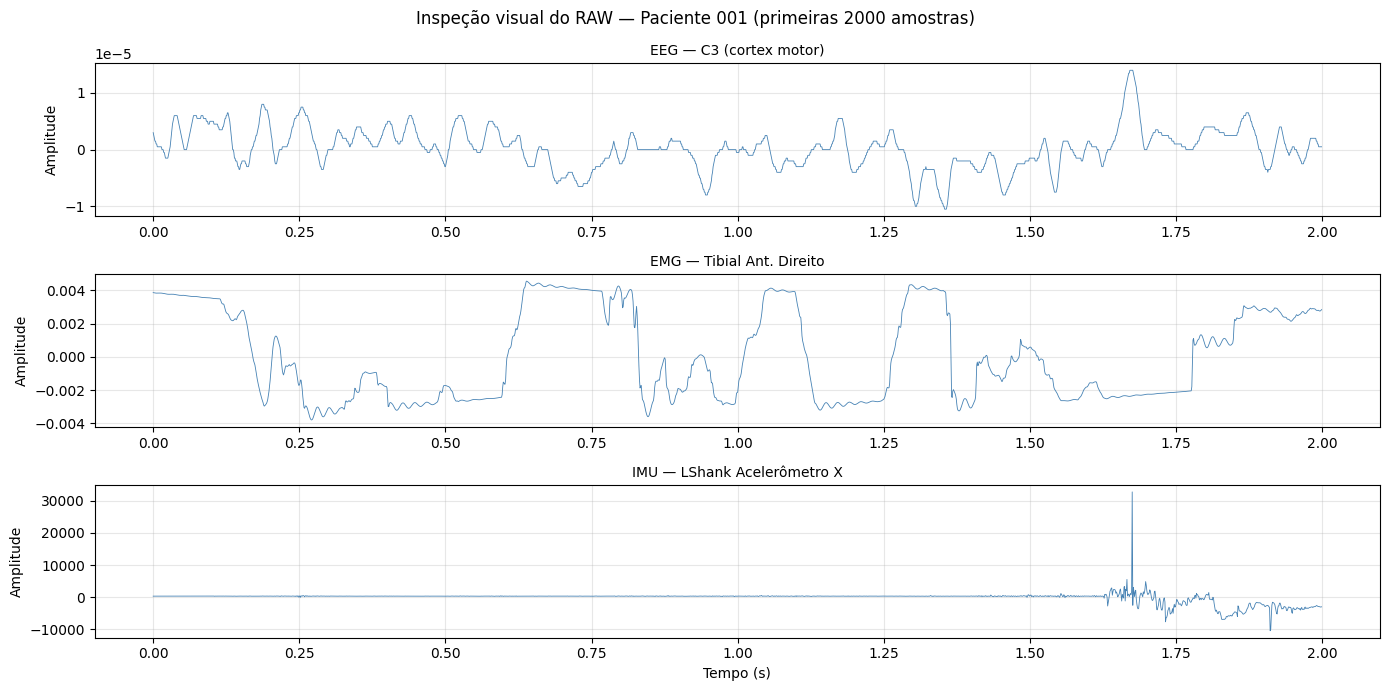

In [17]:
# ── 7.7 Inspeção visual de um trecho de sinal ─────────────────────────────────
# Plota 2 segundos de um canal de cada tipo para checar se o sinal 'parece certo'
# A 1000Hz, 2000 amostras = 2 segundos de EEG
N_AMOSTRAS_PLOT = 2000

pid_ex  = sorted(df_raw['patient_id'].unique())[0]
df_ex   = df_raw[df_raw['patient_id'] == pid_ex]

canais_plot = [
    ('EEG-C3',      'EEG — C3 (cortex motor)'),
    ('EMG-RTA',     'EMG — Tibial Ant. Direito'),
    ('LShank-ACCX', 'IMU — LShank Acelerômetro X'),
]

fig, axes = plt.subplots(len(canais_plot), 1, figsize=(14, 7), sharex=False)
fig.suptitle(f"Inspeção visual do RAW — Paciente {pid_ex} (primeiras {N_AMOSTRAS_PLOT} amostras)",
             fontsize=12)

for ax, (col, titulo) in zip(axes, canais_plot):
    if col in df_ex.columns and df_ex[col].notna().any():
        valores = df_ex[col].dropna().values[:N_AMOSTRAS_PLOT]
        tempo   = np.arange(len(valores)) / EEG_FREQ_HZ   # eixo em segundos
        ax.plot(tempo, valores, linewidth=0.6, color='steelblue')
        ax.set_title(titulo, fontsize=10)
        ax.set_ylabel("Amplitude")
        ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, f"{col} — ausente para este paciente",
                ha='center', va='center', transform=ax.transAxes, color='gray')
        ax.set_title(titulo, fontsize=10)

axes[-1].set_xlabel("Tempo (s)")
plt.tight_layout()
plt.show()

In [18]:
# ── 7.8 Checagem final da referência (sem carregar dados) ─────────────────────
# Apenas verifica se a estrutura de pastas dos task_*.parquet existe
# NÃO carrega nenhum arquivo — isso acontece só na Parte 4
print("VERIFICAÇÃO DA ESTRUTURA DE REFERÊNCIA (task_*.parquet)")
print("(Apenas checa se as pastas existem — NÃO carrega os dados)")
print("-" * 60)

if not FILTERED_REF_PATH.exists():
    print(f"     Pasta de referência não encontrada: {FILTERED_REF_PATH}")
    print("     A Parte 4 (comparação) não poderá ser executada.")
else:
    for pid in sorted(df_raw['patient_id'].unique()):
        pasta_pid = FILTERED_REF_PATH / pid
        if pasta_pid.exists():
            tasks = sorted(pasta_pid.glob("**/task_*.parquet"))
            print(f"  {pid}: {len(tasks)} task_*.parquet encontrados → "
                  f"{[t.name for t in tasks]}")
        else:
            print(f"  {pid}: pasta não encontrada em {pasta_pid}")

print("\n" + "="*60)
print("   Parte 1 concluída.")
print("   Constantes e funções prontas.")
print("   RAW validado estruturalmente.")
print("   Prossiga para a Parte 2: Resample e Merge Temporal.")
print("="*60)

VERIFICAÇÃO DA ESTRUTURA DE REFERÊNCIA (task_*.parquet)
(Apenas checa se as pastas existem — NÃO carrega os dados)
------------------------------------------------------------
  001: 4 task_*.parquet encontrados → ['task_1.parquet', 'task_2.parquet', 'task_3.parquet', 'task_4.parquet']
  002: 4 task_*.parquet encontrados → ['task_1.parquet', 'task_2.parquet', 'task_3.parquet', 'task_4.parquet']
  003: 4 task_*.parquet encontrados → ['task_1.parquet', 'task_2.parquet', 'task_3.parquet', 'task_4.parquet']
  004: 5 task_*.parquet encontrados → ['task_1.parquet', 'task_2.parquet', 'task_3.parquet', 'task_4.parquet', 'task_5.parquet']
  005: 4 task_*.parquet encontrados → ['task_1.parquet', 'task_2.parquet', 'task_3.parquet', 'task_4.parquet']
  006: 4 task_*.parquet encontrados → ['task_1.parquet', 'task_2.parquet', 'task_3.parquet', 'task_4.parquet']
  007: 4 task_*.parquet encontrados → ['task_1.parquet', 'task_2.parquet', 'task_3.parquet', 'task_4.parquet']
  008: 9 task_*.parquet encon